In [1]:
from dask.distributed import Client

client = Client(n_workers=4, threads_per_worker=2, memory_limit='2GB')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 7.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40047,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 7.45 GiB
Comm: tcp://127.0.0.1:40861,Total threads: 2
Dashboard: http://127.0.0.1:42761/status,Memory: 1.86 GiB
Nanny: tcp://127.0.0.1:44531,


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import hvplot.pandas 
import geopandas as gpd

import rioxarray

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb
from lightgbm import LGBMClassifier, plot_importance

from pystac_client import Client as StacClient
import odc.stac
import planetary_computer as pc

time = ("2020-08-01", "2020-08-15")
S2_L2A_RESOLUTION = 10
S2_L2A_MEASUREMENTS = ["B02", "B03", "B04", "B05", "B06","B07","B08","B8A","B09", "B11", "B12", "SCL"]

# Create connection with a STAC endpoint
catalog = StacClient.open("https://planetarycomputer.microsoft.com/api/stac/v1")

odc.stac.configure_rio(cloud_defaults=True, client=client)

## Ground truth
In a Supervised Learning algorithm the ground truth, actual label of samples, must be provided. For a Pixel based classification for Land Cover, the ground truth can be obtained by image interpretation or from land cover products already available, e.g. Copernicus Global Land Cover (100m resolution) and Esa World Cover (10m resolution). The latter leverages on products usually generated with ML methods containining some uncertainity that will affect our classifier. The ground truth used in this notebooks is obtained by the intersection of 5 yearly CGLC maps and the 2020 EWC.

In [3]:
# Ground truth from GeoTIFF file
gt = rioxarray.open_rasterio('ref_map_step0_fm_Lucerne.tiff', masked=True, chunks={'x': 1024, 'y': 1024}).squeeze('band', drop=True)
# gt.plot()

In [4]:
# label, counts = np.unique(gt.data, return_counts=True)
# plt.figure()
# plt.bar(range(len(label[:-1])), counts[:-1], tick_label=label[:-1])
# plt.title("Classes distribution")
# plt.show()

## Training preparation
The classification goal is to create a classifier able to associate a LC class to pixels' spectral signature, coming from different EO products with different resolutions too.
This notebook uses Sentinel-2 L2A products from Microsoft Planetary Computer using Python APIs to query and retreive assets (images) exposed by a STAC catalog as a Xarray Dataset.

Optical data are affected by cloud coverage, so in order to cover an area of interest, a wide time-range can be used and different composition techniques can be applied to fuse data.
Fruthermore, traditional ML packages, like the most popular Scikit-learn, are built for generic purpouses, so they are geospatial unaware. This means that before training/predicting with EO data a preprocessing step is always needed to reshape our data from a cube with spatial, bands and time dimensions to a 2D matrix of m samples and n features, like a table.

In [5]:
# Retrieve GT bounding box using rioxarray accessor
bbox = gt.rio.transform_bounds("EPSG:4326")
bbox

(8.183857250656693, 46.79092298904703, 8.591973439202777, 47.1208893665836)

In [6]:
# Search available items in the STAC catalog with given parameters 
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=time,
    query={
        "eo:cloud_cover": {"lt": 60}
    },
)
items = search.item_collection()
print(f"Found: {len(items)} datasets")

Found: 8 datasets


In [8]:
items[0]

<Item id=S2A_MSIL2A_20200812T103031_R108_T32TMT_20200814T212928>

In [9]:
pc.sign(items[0])

<Item id=S2A_MSIL2A_20200812T103031_R108_T32TMT_20200814T212928>

In [ ]:
gdf = gpd.GeoDataFrame.from_features(items.to_dict(), "epsg:4326")
gdf.explore(
    categorical=True,
    column="datetime",
    tooltip=["s2:product_uri", "datetime", "s2:mgrs_tile"], 
    popup=True,
    tiles="CartoDB Voyager", 
    legend=True,
    style_kwds=dict(fillOpacity=0, width=3),
)

In [7]:
# Load STAC items into a Xarray Dataset
ds = odc.stac.load(
    items,
    time=time,
    bands=S2_L2A_MEASUREMENTS,
    dtype='uint16',
    nodata=0,
    group_by="solar_day",
    fail_on_error=False,
    like=gt,
    chunks={'x': 1024, 'y': 1024, 'time': -1},
    patch_url=pc.sign
)
ds

<xarray.Dataset> Size: 1GB
Dimensions:      (y: 3643, x: 3077, time: 4)
Coordinates:
  * y            (y) float64 29kB 5.219e+06 5.219e+06 ... 5.182e+06 5.182e+06
  * x            (x) float64 25kB 4.381e+05 4.381e+05 ... 4.688e+05 4.689e+05
    spatial_ref  int32 4B 32632
  * time         (time) datetime64[ns] 32B 2020-08-02T10:30:31.024000 ... 202...
Data variables:
    B02          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B03          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B04          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B05          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B06          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B07          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B08          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B8A          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B09          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B11          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    B12          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>
    SCL          (time, y, x) uint16 90MB dask.array<chunksize=(4, 1024, 1024), meta=np.ndarray>

In [8]:
# %%time
# ds.median(dim='time', skipna=True).compute()

In [9]:
# %%time
# ds.chunk(time=-1).median(dim='time', skipna=True).compute()

In [10]:
ds.rio.resolution()

(10.0, -10.0)

In [11]:
ds.rio.crs.to_epsg()

32632

In [12]:
# Mask nodata value (0) as np.NaN
ds = ds.where(ds != 0)

# Mask cloudy pixels using SCL provided by Sen2Cor
ds = ds.where(ds.SCL <= 7)
ds = ds.drop_vars("SCL")

In [13]:
# Mask with GT
ds = ds.where(~gt.isnull())

# Median Composition: each pixels has many observations along the time dimension, retrieve the median values for each band
ds = ds.median(dim='time', skipna=True)
ds['label'] = gt

# Convert back to uint16, replacing NaN with 0
ds = ds.fillna(0).astype("uint16")

ds

<xarray.Dataset> Size: 269MB
Dimensions:      (y: 3643, x: 3077)
Coordinates:
  * y            (y) float64 29kB 5.219e+06 5.219e+06 ... 5.182e+06 5.182e+06
  * x            (x) float64 25kB 4.381e+05 4.381e+05 ... 4.688e+05 4.689e+05
    spatial_ref  int64 8B 0
Data variables:
    B02          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B03          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B04          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B05          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B06          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B07          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B08          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B8A          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B09          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B11          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    B12          (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    label        (y, x) uint16 22MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>

In [14]:
# Convert Xarray Dataset with 2 spatial dimension and different data variables (bands) in a 2D array (table).
# Each row of the array is a sample composed by 11 columns, the respective bands values.
ds = ds.to_stacked_array("z", sample_dims=["x","y"])

cols = ds.x.size
rows = ds.y.size
bands = ds.z.size

ds = ds.data
ds = np.reshape(ds, (rows*cols, bands))
ds.shape

(11209511, 12)

In [15]:
# Remove samples with NaN in spectra or labels
ds = ds[~np.any(ds == 0, axis=1)]
ds

dask.array<getitem_variadic, shape=(nan, 12), dtype=uint16, chunksize=(nan, 1), chunktype=numpy.ndarray>

In [16]:
ds = ds.compute()

/home/simone/geop-env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/home/simone/geop-env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/home/simone/geop-env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/home/simone/geop-env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


In [17]:
# Separate features from labels
X = ds[:, :-1]
y = ds[:, -1]
y

array([30, 30, 30, ..., 60, 60, 60], shape=(6285617,), dtype=uint16)

In [18]:
# First sample features
X[0, :]

array([ 361,  656,  472, 1140, 3000, 3424, 3510, 3827, 3786, 2409, 1244],
      dtype=uint16)

## Dimensionality reduction
Dimensionality reduction is the transformation of data from a high-dimensional space into a low-dimensional space so that the low-dimensional representation retains some meaningful properties of the original data. Working in high-dimensional spaces can be undesirable for many reasons: raw data are often sparse as a consequence of the curse of dimensionality, they require more storage and computational resources, they are really hard to understand and visualize.
Methods are commonly divided into linear and nonlinear approaches, and can be used for noise reduction, data visualization, cluster analysis, or as an intermediate step to facilitate other analyses

Principal Component Analysis, PCA, is the main linear technique for dimensionality reduction and performs a linear mapping of the data to a lower-dimensional space in such a way that the variance of the data in the low-dimensional representation is maximized. This projection causes a loss of information that can be measured with the explained variance, the proportion of the original variance preserved..

In [23]:
from sklearn.decomposition import PCA

# Define number of PCs to use
pca = PCA(n_components=2)

# Retreive the Principal Components from the given dataset
pca.fit(X)

# Print the variance retained by each Principal Component
print(f"PCs explained var.: {pca.explained_variance_ratio_}")
print(f"Total: {sum(pca.explained_variance_ratio_):.2f}")

PCs explained var.: [0.89559222 0.06964119]
Total: 0.97


In [24]:
# Project the dataset with the PCs
X_pca = pca.transform(X)
X_pca.shape

(6285617, 2)

In [25]:
X_pca[0]

array([2089.99632863,   52.03738234])

In [ ]:
# 2D visualization of the reduced space
df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'LC_class': y.astype('uint8')})
df.hvplot.scatter(x='PC1', y='PC2', by='LC_class', legend='right', height=600, width=600)

## Model training
Dataset is splitted in training and test sets: training set is used for model fitting and the test set with the unseen samples shall be used to compute metrics. Using the training samples to compute metrics will lead to an underestimation of the Generalization Error.
Furthermore, before fitting the model, many different preprocessing can be applied to the data, such as normalization, scaling, encoding and so on. Of course, every transformation applied to the training set shall be applied on data before inference so every transformer must be stored.

In [19]:
# Some ML algorithms requires the input label (y) with 0 to n_classes-1 values.
# LabelEncoder creates a mapping between original classes and temporary values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
n_classes = len(label_encoder.classes_)
class_labels = label_encoder.classes_.astype("uint8")
y

array([1, 1, 1, ..., 4, 4, 4], shape=(6285617,))

In [20]:
import pickle

# Save fitted Label Encoder
with open('./label_encoder.pkl', 'wb') as f:      
    pickle.dump(label_encoder, f) 

In [21]:
# Train Test splitting with stratification ensures same samples classes distribution in training and test sets and is recomended for unbalanced datasets.
# Splitting can also shuffle samples, so a random_state shall be provided in order to reproduce results.
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, shuffle=True, random_state=42)

In [22]:
# LGBM and XGBoost model definitions with parameters
model_lgbm = LGBMClassifier(
    objective = "multiclass",
    metric = "multi_logloss",
    n_estimators = 100,
    early_stopping_rounds = 10,
    verbose = 1,
    random_state = 42,
)

model_xgb = xgb.XGBClassifier(
    objective = "multi:softprob",
    metric = "multi_logloss",
    grow_policy = "lossguide",
    verbosity = 0, 
    early_stopping_rounds = 10, 
    n_estimators = 100,
    num_class = n_classes,
    random_state = 42,
    n_jobs=6,
)

Early stopping is a parameter that allows to stop the training process before the defined number of iterations, if the validation metric has not increased in the last n iterations, avoiding overfitting
![title](img/overfitting.jpg)

In [23]:
model_lgbm = model_lgbm.fit(X_train, y_train, eval_set=[(X_test, y_test)])

/home/simone/geop-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] early_stopping_round is set=10, early_stopping_rounds=10 will be ignored. Current value: early_stopping_round=10
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.082222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 5028493, number of used features: 11
[LightGBM] [Warning] early_stopping_round is set=10, early_stopping_rounds=10 will be ignored. Current value: early_stopping_round=10
[LightGBM] [Info] Start training from score -0.851712
[LightGBM] [Info] Start training from score -1.118581
[LightGBM] [Info] Start training from score -4.602547
[LightGBM] [Info] Start training from score -3.399966
[LightGBM] [Info] Start training from score -4.041592
[LightGBM] [Info] Start training from score -5.211639
[LightGBM] [Info] Start training from score -1.714205
[LightGBM] [Info] Start training from score -10.433419
[LightGB

In [24]:
print(f'LGBM best iteration: {model_lgbm.booster_.best_iteration}')

LGBM best iteration: 25


In [25]:
model_xgb = model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)])

[0]	validation_0-mlogloss:1.24084
[1]	validation_0-mlogloss:0.93478
[2]	validation_0-mlogloss:0.74439
[3]	validation_0-mlogloss:0.61481
[4]	validation_0-mlogloss:0.52220
[5]	validation_0-mlogloss:0.45486
[6]	validation_0-mlogloss:0.40525
[7]	validation_0-mlogloss:0.36673
[8]	validation_0-mlogloss:0.33842
[9]	validation_0-mlogloss:0.31635
[10]	validation_0-mlogloss:0.29875
[11]	validation_0-mlogloss:0.28499
[12]	validation_0-mlogloss:0.27423
[13]	validation_0-mlogloss:0.26556
[14]	validation_0-mlogloss:0.25817
[15]	validation_0-mlogloss:0.25217
[16]	validation_0-mlogloss:0.24719
[17]	validation_0-mlogloss:0.24265
[18]	validation_0-mlogloss:0.23892
[19]	validation_0-mlogloss:0.23572
[20]	validation_0-mlogloss:0.23310
[21]	validation_0-mlogloss:0.23087
[22]	validation_0-mlogloss:0.22874
[23]	validation_0-mlogloss:0.22682
[24]	validation_0-mlogloss:0.22504
[25]	validation_0-mlogloss:0.22349
[26]	validation_0-mlogloss:0.22205
[27]	validation_0-mlogloss:0.22073
[28]	validation_0-mlogloss:0.2

In [26]:
print(f'XGB best iteration: {model_xgb.best_iteration}')

XGB best iteration: 99


In [27]:
# Save model on disk
model_lgbm.booster_.save_model('./model_LGBM_Bari.json')
model_xgb.save_model('./model_XGB_Bari.json')

A benefit of using gradient boosting is that after the boosted trees are constructed, it is relatively straightforward to retrieve importance scores for each attribute.

Generally, importance provides a score that indicates how useful or valuable each feature was in the construction of the boosted decision trees within the model. It can be computed in different ways, e.g. counting the times a features has been used for splitting in the decision trees or how much a certain features contributes to accuracy when used for splitting in a trees.

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

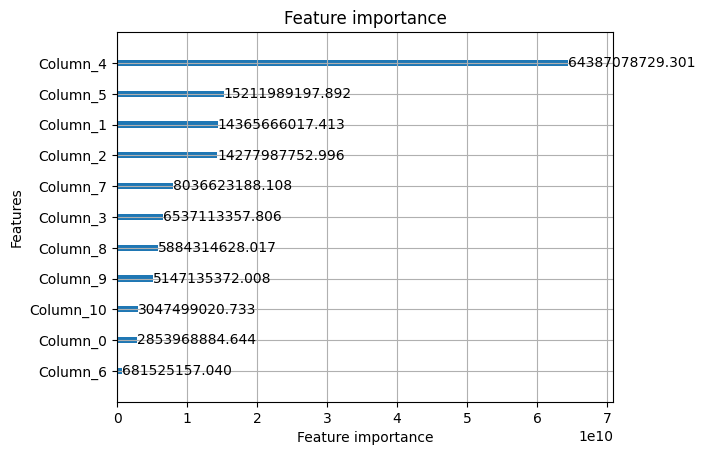

In [28]:
plot_importance(model_lgbm, importance_type='gain')

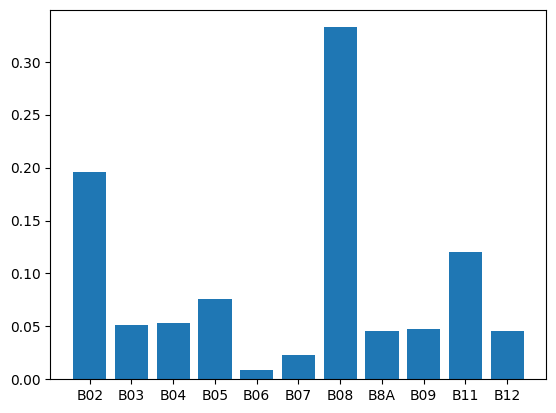

In [29]:
plt.figure()
plt.bar(range(len(model_xgb.feature_importances_)), model_xgb.feature_importances_, tick_label=S2_L2A_MEASUREMENTS[:-1])
plt.show()

## Model Evaluation

The training set separeted before is now used for model evaluation, by making prediction on test samples' features and comparing label predicted with their true values.
Model can be evaluated using different metrics, according to the learning tasks. Common metrics for classification are Accuracy, Precision, Recall and the confusion matrix.

In imbalanced classifications, using just the (overall) accuracy as metric can be misleading: the accuracy is driven by the more occuring classes. Instead the balanced accuracy is defined as the average of recall obtained on each class.

In [30]:
# Predict labels on test set samples
y_lgbm = model_lgbm.predict(X_test)
y_xgb = model_xgb.predict(X_test)

y_xgb

/home/simone/geop-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([6, 0, 6, ..., 6, 0, 0], shape=(1257124,))

In [31]:
# Decode temporary class values to initial ones
y_test = label_encoder.inverse_transform(y_test).astype("uint8")
y_lgbm = label_encoder.inverse_transform(y_lgbm).astype("uint8")
y_xgb = label_encoder.inverse_transform(y_xgb).astype("uint8")

y_xgb

array([80, 10, 80, ..., 80, 10, 10], shape=(1257124,), dtype=uint8)

In [32]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, recall_score

# Compute Accuracy and Balanced Accuracy
print(f"LGBM Accuracy: {accuracy_score(y_test, y_lgbm):.2f}")
print(f"LGBM Balanced Accuracy: {balanced_accuracy_score(y_test, y_lgbm):.2f}\n")

print(f"XGB Accuracy: {accuracy_score(y_test, y_xgb):.2f}")
print(f"XGB Balanced Accuracy: {balanced_accuracy_score(y_test, y_xgb):.2f}")

LGBM Accuracy: 0.91
LGBM Balanced Accuracy: 0.65

XGB Accuracy: 0.93
XGB Balanced Accuracy: 0.77


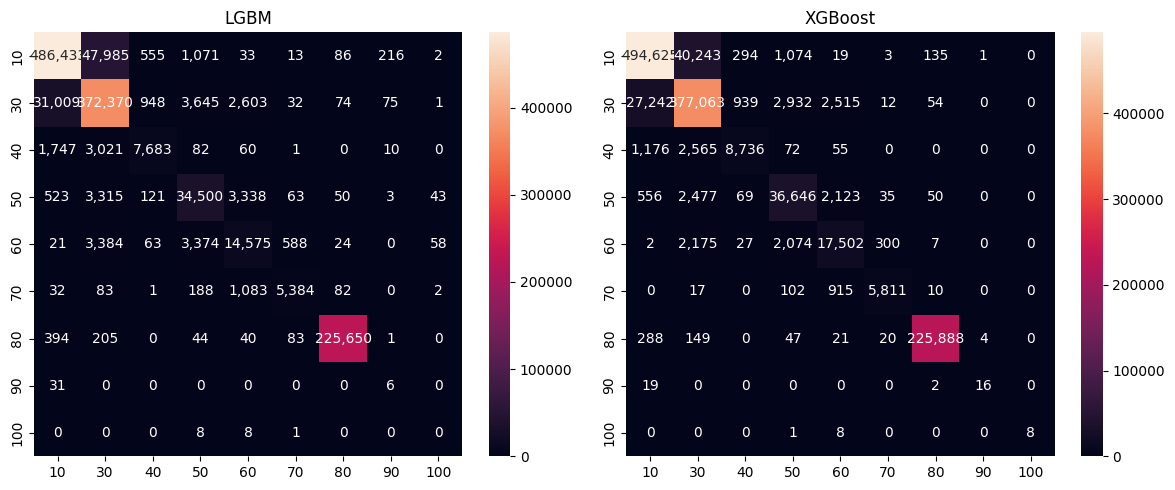

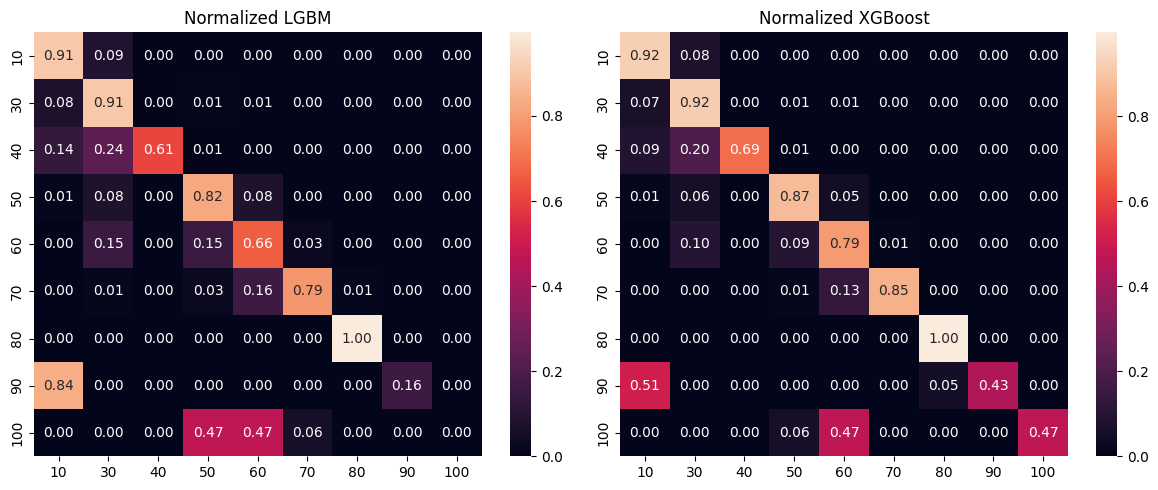

In [33]:
# Confusion Matrix
fig = plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_lgbm), annot=True, fmt=",d", xticklabels=class_labels, yticklabels=class_labels)
plt.title("LGBM")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_xgb), annot=True, fmt=",d", xticklabels=class_labels, yticklabels=class_labels)
plt.title("XGBoost")

plt.tight_layout()
plt.show()

# Normalized Confusion Matrix
fig = plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_lgbm, normalize='true'), annot=True, fmt=".2f", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Normalized LGBM")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_xgb, normalize='true'), annot=True, fmt=".2f", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Normalized XGBoost")

plt.tight_layout()
plt.show()

In [34]:
# Compute classes recall
recall_score(y_test, y_xgb, average=None)

array([0.92213   , 0.91797097, 0.6931133 , 0.87343884, 0.79241183,
       0.84770241, 0.9976636 , 0.43243243, 0.47058824])

In [35]:
client.close()